In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
model_df = pd.read_csv(
    "D:/clg_project/AI-Financial-Wellness-Coach/data/processed/expense_features.csv"
)

print(model_df.shape)

(7000, 7)


## Data Validation

In [11]:
model_df.head(5)

,transaction_text,amount,amount_log,amount_bucket,payment_method,transaction_type,category
0,Credit Card Bill Payment Auto Debit Credit Car...,4361.84,8.380879,Large,Auto Debit,Debit,Bills
1,Zepto UPI/Paytm/Zepto,1226.03,7.112352,Medium,Upi,Debit,Groceries
2,Ace Hardware India POS Purchase Ace Hardware I...,523.73,6.262884,Small,Credit Card,Debit,Miscellaneous
3,Zepto UPI/DR/623175732898/Zepto,1290.29,7.163397,Medium,Upi,Debit,Groceries
4,House Rent Payment NEFT Rent Payment,44800.94,10.710007,Large,Neft,Debit,Rent


In [12]:


print("\nMissing values:")
print(model_df.isnull().sum())




Missing values:
transaction_text    0
amount              0
amount_log          0
amount_bucket       0
payment_method      0
transaction_type    0
category            0
dtype: int64


In [13]:
print("\nData types:")
print(model_df.dtypes)


Data types:
transaction_text     object
amount              float64
amount_log          float64
amount_bucket        object
payment_method       object
transaction_type     object
category             object
dtype: object


In [14]:

print("\nDuplicate rows:")
print(model_df.duplicated().sum())


Duplicate rows:
222


In [15]:
print("\nUnique transaction texts:")
print(model_df["transaction_text"].nunique())


Unique transaction texts:
1209


In [16]:

print("\nEmpty transaction texts:")
print(
    (model_df["transaction_text"].astype(str).str.strip() == "").sum()
)


Empty transaction texts:
0


In [17]:
model_df.category.unique()

array(['Bills', 'Groceries', 'Miscellaneous', 'Rent', 'Food',
       'Entertainment', 'Shopping', 'Fuel', 'Subscription', 'Salary',
       'Insurance', 'Other', 'Investment'], dtype=object)

In [18]:
category_distribution = (
    model_df["category"]
    .value_counts()
    .to_frame("count")
)

category_distribution["percentage"] = (
    category_distribution["count"]
    / len(model_df)
    * 100
).round(2)

print(category_distribution)

               count  percentage
category                        
Bills           2059       29.41
Food            1328       18.97
Groceries        912       13.03
Shopping         550        7.86
Other            435        6.21
Fuel             423        6.04
Miscellaneous    358        5.11
Subscription     242        3.46
Salary           173        2.47
Entertainment    167        2.39
Rent             165        2.36
Insurance        152        2.17
Investment        36        0.51


## EDA

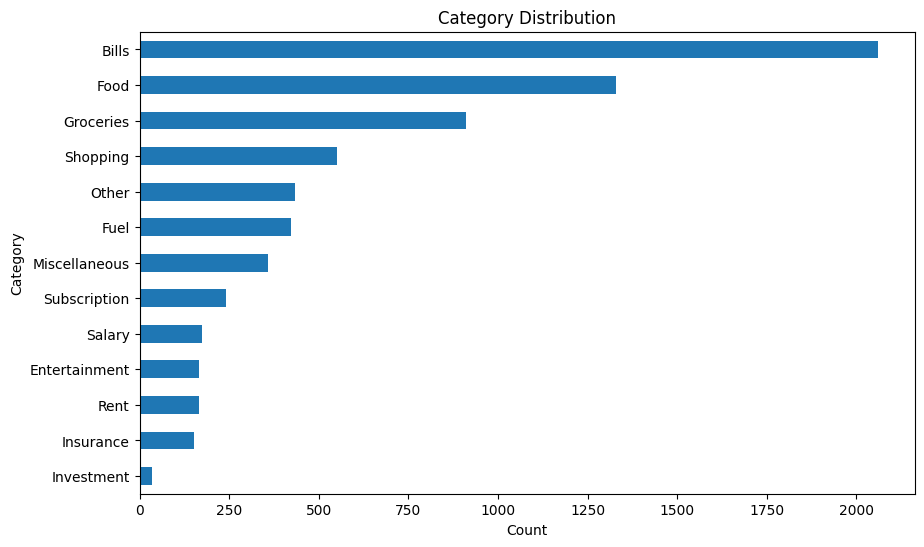

In [19]:
# Category distribution plot

model_df['category'].value_counts().sort_values().plot(kind='barh', figsize=(10, 6))

plt.title('Category Distribution')
plt.xlabel('Count')  
plt.ylabel('Category')
plt.show()

In [20]:
# Text Length Analysis

model_df['text_len'] = model_df['transaction_text'].astype(str).str.len()
model_df['text_len'].describe()

count    7000.000000
mean       36.537286
std        13.960665
min        11.000000
25%        25.000000
50%        33.000000
75%        44.000000
max        73.000000
Name: text_len, dtype: float64

In [21]:
model_df[['transaction_text' , 'text_len']]

,transaction_text,text_len
0,Credit Card Bill Payment Auto Debit Credit Car...,60
1,Zepto UPI/Paytm/Zepto,21
2,Ace Hardware India POS Purchase Ace Hardware I...,50
3,Zepto UPI/DR/623175732898/Zepto,31
4,House Rent Payment NEFT Rent Payment,36
...,...,...
6995,Myntra POS Purchase Myntra,26
6996,Flipkart UPI/Paytm/Flipkart,27
6997,Nykaa UPI/Nykaa,15
6998,Amazon India UPI/Paytm/Amazon India,35


In [22]:
import re 
model_df['transaction_text'] = model_df['transaction_text'].str.replace(r'[/]' , ' ' , regex = True)

In [23]:
#Analyzing Number of Words

model_df['word_count'] = model_df['transaction_text'].astype(str).str.split().str.len()

In [24]:
model_df[['transaction_text' , 
          'text_len' , 'word_count']]

,transaction_text,text_len,word_count
0,Credit Card Bill Payment Auto Debit Credit Car...,60,10
1,Zepto UPI Paytm Zepto,21,4
2,Ace Hardware India POS Purchase Ace Hardware I...,50,8
3,Zepto UPI DR 623175732898 Zepto,31,5
4,House Rent Payment NEFT Rent Payment,36,6
...,...,...,...
6995,Myntra POS Purchase Myntra,26,4
6996,Flipkart UPI Paytm Flipkart,27,4
6997,Nykaa UPI Nykaa,15,3
6998,Amazon India UPI Paytm Amazon India,35,6


In [25]:
model_df.columns

Index(['transaction_text', 'amount', 'amount_log', 'amount_bucket',
       'payment_method', 'transaction_type', 'category', 'text_len',
       'word_count'],
      dtype='object')

In [26]:

model_df[
        ["transaction_text", "category" , "text_len"]
    ].sort_values("text_len").head(30)


,transaction_text,category,text_len
4676,Jio UPI Jio,Bills,11
4552,Ola UPI Ola,Miscellaneous,11
4768,Jio UPI Jio,Bills,11
3330,Jio UPI Jio,Bills,11
4480,Jio UPI Jio,Bills,11
4155,Jio UPI Jio,Bills,11
4312,Jio UPI Jio,Bills,11
5521,KFC UPI KFC,Food,11
6464,KFC UPI KFC,Food,11
6441,KFC UPI KFC,Food,11


In [27]:
model_df['text_len'].min()

np.int64(11)

In [28]:

model_df[
        ["transaction_text", "category" , "text_len"]
    ].sort_values("text_len" , ascending = False).head(30)


,transaction_text,category,text_len
733,Municipal Water Department Net Banking Payment...,Bills,73
4615,Municipal Water Department Net Banking Payment...,Bills,73
2941,Municipal Water Department Net Banking Payment...,Bills,73
4617,Municipal Water Department Net Banking Payment...,Bills,73
1597,Municipal Water Department Net Banking Payment...,Bills,73
1758,Municipal Water Department UPI DR 616338874599...,Bills,73
187,Municipal Water Department UPI DR 687816574852...,Bills,73
4236,Municipal Water Department Net Banking Payment...,Bills,73
4794,Municipal Water Department Net Banking Payment...,Bills,73
4894,Municipal Water Department Net Banking Payment...,Bills,73


## Transactions by Category

In [29]:
for category in model_df["category"].unique():

    print("\n" + "=" * 60)
    print(category)
    print("=" * 60)

    samples = (
        model_df[
            model_df["category"] == category
        ]["transaction_text"]
        .sample(
            min(5, len(model_df[model_df["category"] == category])),
            random_state=42
        )
    )

    for text in samples:
        print("-", text)


Bills
- Bharat Gas Net Banking Payment Bharat Gas
- Credit Card Bill Payment Auto Debit Credit Card Bill Payment
- Jio Fiber Auto Debit Jio Fiber
- Credit Card Bill Payment UPI Credit Card Bill Payment
- Jio Auto Debit Jio

Groceries
- Blinkit UPI DR 310369078 Blinkit
- Nature's Basket UPI DR 453932473 Nature's Basket
- Nature's Basket Debit Card Nature's Basket
- Blinkit Debit Card Blinkit
- Zepto UPI DR 204922732 Zepto

Miscellaneous
- Tata 1mg Debit Card Tata 1mg
- Local Hardware Store POS Purchase Local Hardware Store
- Rapido UPI Rapido
- Home Depot India UPI DR 550535651 Home Depot India
- Local Hardware Store Debit Card POS Local Hardware Store

Rent
- House Rent Payment NEFT House Rent Payment
- House Rent Payment NEFT Rent Payment
- House Rent Payment NEFT House Rent Payment
- House Rent Payment NEFT Rent Payment
- House Rent Payment IMPS Rent Payment

Food
- Zomato POS Purchase Zomato
- Faasos POS Purchase Faasos
- Barbeque Nation UPI DR 466534208 Barbeque Nation
- Cafe Coff

In [30]:
text_frequency = (
    model_df["transaction_text"]
    .value_counts()
)

print(text_frequency.head(30))

transaction_text
Credit Card Bill Payment Auto Debit Credit Card Bill Payment             369
Credit Card Bill Payment Net Banking Payment Credit Card Bill Payment    273
Employer Salary Credit NEFT Salary Credit                                163
Airtel Auto Debit Airtel                                                  85
Municipal Water Department Auto Debit Municipal Water Department          79
Amazon India POS Purchase Amazon India                                    70
Jio Auto Debit Jio                                                        67
Spotify Auto Debit Spotify                                                60
Jio Fiber Auto Debit Jio Fiber                                            58
BSNL Auto Debit BSNL                                                      57
House Rent Payment NEFT Rent Payment                                      56
Zomato UPI Paytm Zomato                                                   55
Flipkart POS Purchase Flipkart                             

In [31]:
text_category_counts = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

conflicting_texts = text_category_counts[
    text_category_counts > 1
]

print("Conflicting transaction texts:", len(conflicting_texts))
print(conflicting_texts.head(30))

Conflicting transaction texts: 5
transaction_text
Amazon Prime UPI Amazon Prime                2
Amazon Prime UPI Paytm Amazon Prime          2
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Netflix UPI Netflix                          2
Name: category, dtype: int64


In [32]:
conflicting_records = model_df[
    model_df["transaction_text"].isin(conflicting_texts.index)
].sort_values("transaction_text")

print(
    conflicting_records[
        [
            "transaction_text",
            "amount",
            "amount_log",
            "payment_method",
            "transaction_type",
            "category"
        ]
    ].to_string(index=False)
)

                         transaction_text  amount  amount_log payment_method transaction_type      category
            Amazon Prime UPI Amazon Prime  683.41    6.528557            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  789.18    6.672261            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime 1492.31    7.308750            Upi            Debit Entertainment
            Amazon Prime UPI Amazon Prime  645.56    6.471666            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  221.98    5.407082            Upi            Debit Entertainment
      Amazon Prime UPI Paytm Amazon Prime  658.75    6.491861            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime  512.88    6.241990            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime 1514.13    7.323257            Upi            Debit Entertainment
      Amazon Prime UPI Paytm

In [33]:
payment_category_pct = pd.crosstab(
    model_df["payment_method"],
    model_df["category"],
    normalize="index"
) * 100

print(payment_category_pct.round(2))

category         Bills  Entertainment   Food   Fuel  Groceries  Insurance  \
payment_method                                                              
Auto Debit       78.17           0.00   0.00   0.00       0.00       6.30   
Cash Withdrawal   0.00           0.00   0.00  32.63       0.00       0.00   
Credit Card       0.00           6.31  29.84   2.73      18.79       0.00   
Debit Card        0.00           3.99  31.43  13.87      23.93       0.00   
Imps              0.00           0.00   0.00   0.00       0.00       0.00   
Neft             29.64           0.00   0.00   0.00       0.00       0.00   
Net Banking      83.58           0.00   0.00   0.86       0.00       8.33   
Upi               9.36           3.11  30.26   8.44      20.29       0.00   

category         Investment  Miscellaneous  Other   Rent  Salary  Shopping  \
payment_method                                                               
Auto Debit             1.43           0.00   0.00   0.00    0.00      0.0

In [34]:
type_category_pct = pd.crosstab(
    model_df["transaction_type"],
    model_df["category"],
    normalize="index"
) * 100

print(type_category_pct.round(2))

category          Bills  Entertainment  Food  Fuel  Groceries  Insurance  \
transaction_type                                                           
Credit             0.00           0.00   0.0  0.00       0.00       0.00   
Debit             30.23           2.45  19.5  6.21      13.39       2.23   

category          Investment  Miscellaneous  Other  Rent  Salary  Shopping  \
transaction_type                                                             
Credit                  0.00           0.00   0.00  0.00   91.05      8.95   
Debit                   0.53           5.26   6.39  2.42    0.00      7.83   

category          Subscription  
transaction_type                
Credit                    0.00  
Debit                     3.55  


In [35]:
amount_stats = (
    model_df
    .groupby("category")["amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

print(amount_stats)

               count          mean     median      min        max
category                                                         
Salary           173  64481.613931  46862.710   114.38  240125.84
Rent             165  26602.182848  30940.780  7542.54   47664.75
Investment        36  22752.809444  20718.725  2485.40   48875.36
Insurance        152  14284.709079   8584.340  2237.12   48355.87
Fuel             423   2968.794468   3097.930   282.59    5000.00
Bills           2059   4498.560690   2734.380   187.00   39289.29
Shopping         550   4272.011818   1317.845   288.00   49971.86
Miscellaneous    358   1777.411397    875.750    60.00   14131.51
Groceries        912   1301.034156    855.480   300.00    4978.56
Other            435   1013.270575    783.330    30.74    4785.00
Food            1328    805.576498    469.685   116.00    2990.00
Entertainment    167    587.277665    325.250   149.00    1990.41
Subscription     242    385.214298    303.985   149.00     850.00


In [36]:
duplicates = model_df[
    model_df.duplicated(keep=False)
]

duplicate_category_check = (
    duplicates
    .groupby([
        "transaction_text",
        "amount",
        "amount_log",
        "payment_method",
        "transaction_type"
    ])["category"]
    .nunique()
)

print(duplicate_category_check.value_counts())

category
1    67
Name: count, dtype: int64


In [37]:
model_df.drop(columns=['amount_bucket'])

,transaction_text,amount,amount_log,payment_method,transaction_type,category,text_len,word_count
0,Credit Card Bill Payment Auto Debit Credit Car...,4361.84,8.380879,Auto Debit,Debit,Bills,60,10
1,Zepto UPI Paytm Zepto,1226.03,7.112352,Upi,Debit,Groceries,21,4
2,Ace Hardware India POS Purchase Ace Hardware I...,523.73,6.262884,Credit Card,Debit,Miscellaneous,50,8
3,Zepto UPI DR 623175732898 Zepto,1290.29,7.163397,Upi,Debit,Groceries,31,5
4,House Rent Payment NEFT Rent Payment,44800.94,10.710007,Neft,Debit,Rent,36,6
...,...,...,...,...,...,...,...,...
6995,Myntra POS Purchase Myntra,46249.96,10.741837,Net Banking,Debit,Shopping,26,4
6996,Flipkart UPI Paytm Flipkart,13526.99,9.512516,Upi,Debit,Shopping,27,4
6997,Nykaa UPI Nykaa,13617.06,9.519152,Upi,Debit,Shopping,15,3
6998,Amazon India UPI Paytm Amazon India,12764.93,9.454535,Upi,Debit,Shopping,35,6


In [38]:
print(
    "Repeated transaction texts:",
    (text_frequency > 1).sum()
)

Repeated transaction texts: 495


In [39]:
text_category_counts = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

conflicting_texts = (
    text_category_counts[
        text_category_counts > 1
    ]
)

print("Conflicting transaction texts:", len(conflicting_texts))

Conflicting transaction texts: 5


In [40]:
print(conflicting_texts.head(30))

transaction_text
Amazon Prime UPI Amazon Prime                2
Amazon Prime UPI Paytm Amazon Prime          2
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Netflix UPI Netflix                          2
Name: category, dtype: int64


In [41]:
for text in conflicting_texts.head(20).index:

    print("\n", text)

    print(
        model_df[
            model_df["transaction_text"] == text
        ][["transaction_text", "category"]]
        .drop_duplicates()
        .to_string(index=False)
    )


 Amazon Prime UPI Amazon Prime
             transaction_text      category
Amazon Prime UPI Amazon Prime  Subscription
Amazon Prime UPI Amazon Prime Entertainment

 Amazon Prime UPI Paytm Amazon Prime
                   transaction_text      category
Amazon Prime UPI Paytm Amazon Prime  Subscription
Amazon Prime UPI Paytm Amazon Prime Entertainment

 Disney+ Hotstar UPI Disney+ Hotstar
                   transaction_text      category
Disney+ Hotstar UPI Disney+ Hotstar  Subscription
Disney+ Hotstar UPI Disney+ Hotstar Entertainment

 Disney+ Hotstar UPI Paytm Disney+ Hotstar
                         transaction_text      category
Disney+ Hotstar UPI Paytm Disney+ Hotstar  Subscription
Disney+ Hotstar UPI Paytm Disney+ Hotstar Entertainment

 Netflix UPI Netflix
   transaction_text      category
Netflix UPI Netflix  Subscription
Netflix UPI Netflix Entertainment


In [42]:
payment_category_pct = pd.crosstab(
    model_df["payment_method"],
    model_df["category"],
    normalize="index"
) * 100

print(payment_category_pct.round(2))


category         Bills  Entertainment   Food   Fuel  Groceries  Insurance  \
payment_method                                                              
Auto Debit       78.17           0.00   0.00   0.00       0.00       6.30   
Cash Withdrawal   0.00           0.00   0.00  32.63       0.00       0.00   
Credit Card       0.00           6.31  29.84   2.73      18.79       0.00   
Debit Card        0.00           3.99  31.43  13.87      23.93       0.00   
Imps              0.00           0.00   0.00   0.00       0.00       0.00   
Neft             29.64           0.00   0.00   0.00       0.00       0.00   
Net Banking      83.58           0.00   0.00   0.86       0.00       8.33   
Upi               9.36           3.11  30.26   8.44      20.29       0.00   

category         Investment  Miscellaneous  Other   Rent  Salary  Shopping  \
payment_method                                                               
Auto Debit             1.43           0.00   0.00   0.00    0.00      0.0

In [43]:
type_category = pd.crosstab(
    model_df["transaction_type"],
    model_df["category"]
)

print(type_category)

category          Bills  Entertainment  Food  Fuel  Groceries  Insurance  \
transaction_type                                                           
Credit                0              0     0     0          0          0   
Debit              2059            167  1328   423        912        152   

category          Investment  Miscellaneous  Other  Rent  Salary  Shopping  \
transaction_type                                                             
Credit                     0              0      0     0     173        17   
Debit                     36            358    435   165       0       533   

category          Subscription  
transaction_type                
Credit                       0  
Debit                      242  


In [44]:
type_category_pct = pd.crosstab(
    model_df["transaction_type"],
    model_df["category"],
    normalize="index"
) * 100

print(type_category_pct.round(2))

category          Bills  Entertainment  Food  Fuel  Groceries  Insurance  \
transaction_type                                                           
Credit             0.00           0.00   0.0  0.00       0.00       0.00   
Debit             30.23           2.45  19.5  6.21      13.39       2.23   

category          Investment  Miscellaneous  Other  Rent  Salary  Shopping  \
transaction_type                                                             
Credit                  0.00           0.00   0.00  0.00   91.05      8.95   
Debit                   0.53           5.26   6.39  2.42    0.00      7.83   

category          Subscription  
transaction_type                
Credit                    0.00  
Debit                     3.55  


In [45]:
amount_stats = (
    model_df
    .groupby("category")["amount"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .sort_values("median", ascending=False)
)

print(amount_stats)

               count          mean     median      min        max
category                                                         
Salary           173  64481.613931  46862.710   114.38  240125.84
Rent             165  26602.182848  30940.780  7542.54   47664.75
Investment        36  22752.809444  20718.725  2485.40   48875.36
Insurance        152  14284.709079   8584.340  2237.12   48355.87
Fuel             423   2968.794468   3097.930   282.59    5000.00
Bills           2059   4498.560690   2734.380   187.00   39289.29
Shopping         550   4272.011818   1317.845   288.00   49971.86
Miscellaneous    358   1777.411397    875.750    60.00   14131.51
Groceries        912   1301.034156    855.480   300.00    4978.56
Other            435   1013.270575    783.330    30.74    4785.00
Food            1328    805.576498    469.685   116.00    2990.00
Entertainment    167    587.277665    325.250   149.00    1990.41
Subscription     242    385.214298    303.985   149.00     850.00


In [46]:
amount_log_stats = (
    model_df
    .groupby("category")["amount_log"]
    .agg(
        ["mean", "median", "min", "max"]
    )
)

print(amount_log_stats)

                    mean     median       min        max
category                                                
Bills           7.834272   7.914026  5.236442  10.578733
Entertainment   6.087225   5.787664  5.010635   7.596598
Food            6.233849   6.154186  4.762174   8.003363
Fuel            7.902205   8.038812  5.647530   8.517393
Groceries       6.877358   6.752829  5.707110   8.513097
Insurance       9.346396   9.057811  7.713392  10.786364
Investment      9.750140   9.938839  7.818591  10.797049
Miscellaneous   6.814400   6.776204  4.110874   9.556233
Other           6.406050   6.664830  3.457578   8.473450
Rent            9.943971  10.339863  8.928447  10.771968
Salary         10.725999  10.754999  4.748231  12.388923
Shopping        7.376226   7.184483  5.666427  10.819235
Subscription    5.752410   5.720257  5.010635   6.746412


In [47]:
duplicates = model_df[
    model_df.duplicated(keep=False)
].sort_values(
    by=model_df.columns.tolist()
)

print(duplicates.shape)

print(
    duplicates.head(30).to_string(index=False)
)

(289, 9)
                         transaction_text  amount  amount_log amount_bucket payment_method transaction_type      category  text_len  word_count
Ace Hardware India UPI Ace Hardware India    60.0    4.110874         Small            Upi            Debit Miscellaneous        41           7
Ace Hardware India UPI Ace Hardware India    60.0    4.110874         Small            Upi            Debit Miscellaneous        41           7
                     Ajio Debit Card Ajio   288.0    5.666427         Small     Debit Card            Debit      Shopping        20           4
                     Ajio Debit Card Ajio   288.0    5.666427         Small     Debit Card            Debit      Shopping        20           4
                     Ajio Debit Card Ajio   288.0    5.666427         Small     Debit Card            Debit      Shopping        20           4
                   Ajio POS Purchase Ajio   288.0    5.666427         Small    Credit Card            Debit      Shopping      

In [48]:
duplicate_category_check = (
    duplicates
    .groupby(
        [
            "transaction_text",
            "amount",
            "amount_log",
            "payment_method",
            "transaction_type"
        ]
    )["category"]
    .nunique()
)

print(
    duplicate_category_check
    .value_counts()
)

category
1    67
Name: count, dtype: int64


In [49]:
exact_duplicates = model_df.duplicated().sum()

print(
    "Exact duplicate rows:",
    exact_duplicates
)

Exact duplicate rows: 222


In [50]:
print(
    model_df[
        model_df.duplicated(keep=False)
    ]["category"]
    .value_counts()
)

category
Shopping         105
Food             101
Subscription      32
Bills             23
Groceries         17
Miscellaneous      8
Insurance          3
Name: count, dtype: int64


In [51]:
print("Before removing exact duplicates:", model_df.shape)

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("After removing exact duplicates:", model_df.shape)

Before removing exact duplicates: (7000, 9)
After removing exact duplicates: (6778, 9)


In [52]:
print("Before removing exact duplicates:", model_df.shape)

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("After removing exact duplicates:", model_df.shape)

Before removing exact duplicates: (6778, 9)
After removing exact duplicates: (6778, 9)


In [53]:
print("Before removing exact duplicates:", model_df.shape)

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("After removing exact duplicates:", model_df.shape)

Before removing exact duplicates: (6778, 9)
After removing exact duplicates: (6778, 9)


## Train / Validation / Test Split

### Now we separate the data into three datasets:

70% → Training,
15% → Validation,
15% → Test

In [54]:
feature_columns = [
    "transaction_text",
    "amount",
    "amount_log",
    "payment_method",
    "transaction_type"
]

target_column = "category"

X = model_df[feature_columns].copy()
y = model_df[target_column].copy()

In [55]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6778, 5)
y shape: (6778,)


### First split: separate Test set

In [56]:
# Use train_test_split

from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# X_test = 15%
# y_test = 15%

# X_temp = 85%
# y_temp = 85%

# Test = 1,050
# Remaining = 5,950

### Second split: Training and Validation

We want validation to ultimately be 15% of the entire dataset.

Currently we have 85% remaining.

Therefore:

15 / 85 = 0.17647

So we take approximately 17.65% of the remaining data for validation.

In [57]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.17647,
    stratify=y_temp,
    random_state=42
)

# Now approximately:

'''Train → 70%
Validation → 15%
Test → 15%'''

'Train → 70%\nValidation → 15%\nTest → 15%'

### Verify the Shapes

In [58]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (4744, 5)
Validation: (1017, 5)
Test: (1017, 5)


### Verify Total Rows

In [59]:
print(
    len(X_train)
    + len(X_val)
    + len(X_test)
)

print(
    len(y_train)
    + len(y_val)
    + len(y_test)
)

6778
6778


### Verify Category Distribution

In [60]:
print("TRAIN")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nVALIDATION")
print(y_val.value_counts(normalize=True).mul(100).round(2))

print("\nTEST")
print(y_test.value_counts(normalize=True).mul(100).round(2))

TRAIN
category
Bills            30.14
Food             18.42
Groceries        13.32
Shopping          6.83
Other             6.43
Fuel              6.24
Miscellaneous     5.23
Subscription      3.18
Salary            2.55
Entertainment     2.47
Rent              2.42
Insurance         2.21
Investment        0.55
Name: proportion, dtype: float64

VALIDATION
category
Bills            30.09
Food             18.49
Groceries        13.37
Shopping          6.78
Other             6.39
Fuel              6.29
Miscellaneous     5.21
Subscription      3.24
Salary            2.56
Entertainment     2.46
Rent              2.46
Insurance         2.16
Investment        0.49
Name: proportion, dtype: float64

TEST
category
Bills            30.19
Food             18.49
Groceries        13.27
Shopping          6.78
Other             6.39
Fuel              6.19
Miscellaneous     5.21
Subscription      3.24
Salary            2.56
Entertainment     2.46
Rent              2.46
Insurance         2.26
Investmen

### Check the Smallest Class

In [61]:
print("Investment counts:")

print(
    "Train:",
    (y_train == "Investment").sum()
)

print(
    "Validation:",
    (y_val == "Investment").sum()
)

print(
    "Test:",
    (y_test == "Investment").sum()
)

Investment counts:
Train: 26
Validation: 5
Test: 5


### Check for Data Leakage

In [62]:
train_rows = set(
    X_train.astype(str).agg("|".join, axis=1)
)

val_rows = set(
    X_val.astype(str).agg("|".join, axis=1)
)

test_rows = set(
    X_test.astype(str).agg("|".join, axis=1)
)

print("Train ∩ Validation:", len(train_rows & val_rows))
print("Train ∩ Test:", len(train_rows & test_rows))
print("Validation ∩ Test:", len(val_rows & test_rows))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## Build the Preprocessing Pipeline

### Our input features are:

transaction_text → TF-IDF

amount            → Numeric

amount_log        → Numeric

payment_method    → One-Hot Encoding

transaction_type  → One-Hot Encoding

Target:
category

In [63]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Defining the columns

In [64]:
text_features = "transaction_text"

numeric_features = [
    "amount",
    "amount_log"
]

categorical_features = [
    "payment_method",
    "transaction_type"
]

### Creating TF-IDF

In [65]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

### Creating categorical encoder

In [66]:
encoder = OneHotEncoder(
    handle_unknown="ignore"
)

### Creating numeric scaler

In [67]:
scaler = StandardScaler()

### Building the ColumnTransformer

In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            tfidf,
            text_features
        ),
        (
            "numeric",
            scaler,
            numeric_features
        ),
        (
            "categorical",
            encoder,
            categorical_features
        )
    ]
)

### Fit ONLY on training data

In [69]:
X_train_transformed = preprocessor.fit_transform(X_train)

In [70]:
X_val_transformed = preprocessor.transform(X_val)

In [71]:
X_test_transformed = preprocessor.transform(X_test)

In [72]:
preprocessor.fit_transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11775 stored elements and shape (1017, 563)>

### Check the transformed shapes

In [73]:
print("Original training shape:", X_train.shape)
print("Transformed training shape:", X_train_transformed.shape)

print("Original validation shape:", X_val.shape)
print("Transformed validation shape:", X_val_transformed.shape)

print("Original test shape:", X_test.shape)
print("Transformed test shape:", X_test_transformed.shape)

Original training shape: (4744, 5)
Transformed training shape: (4744, 907)
Original validation shape: (1017, 5)
Transformed validation shape: (1017, 907)
Original test shape: (1017, 5)
Transformed test shape: (1017, 907)
